In [2]:
%load_ext autoreload
%autoreload 2
%env CUDA_VISIBLE_DEVICES=1

import numpy as np
import sys
import os
import matplotlib.pyplot as plt
import vis_utils

from utils.utils import get_path
from utils.io_utils import load_multiple_res
from utils.toydata_utils import get_toy_data
from utils.fig_utils import dataset_to_print, plot_dgm_loops, dist_to_print, fig_loops
from utils.pd_utils import sort_cycle, get_life_times
from utils.passing_cells_utils import fig_distribution, fig_loops_curve

from vis_utils.loaders import load_dataset
from vis_utils.plot import plot_scatter
from vis_utils.utils import load_dict, save_dict
from vis_utils.tsne_wrapper import TSNEwrapper
from openTSNE.affinity import Affinities

import umap
from ripser import Rips
from ripser.ripser import get_greedy_perm

from mpl_toolkits.axes_grid1 import make_axes_locatable

from matplotlib import collections  as mc
from matplotlib.colors import Normalize
import matplotlib.cm

from openTSNE.nearest_neighbors import PrecomputedNeighbors
from openTSNE.affinity import PerplexityBasedNN

from vis_utils.utils import kNN_graph, kNN_dists
from scipy.spatial.distance import pdist, squareform
import glasbey
import scipy.sparse
import networkx as nx

from sklearn.decomposition import PCA

from persim import plot_diagrams
from utils.pd_utils import get_life_times
import pandas as pd

from vis_utils.rnaseqTools import geneSelection, sparseload
import pickle
import torch
import urllib.request
import requests
 

env: CUDA_VISIBLE_DEVICES=1
[KeOps] Warning : cuda was detected, but driver API could not be initialized. Switching to cpu only.


In [2]:
root_path = get_path("data")
fig_path = get_path("figures")
# seeds = [0, 1, 2]
seeds = [0]
k = 15

style_file = "utils.style"
plt.style.use(style_file)

distances = {
    "euclidean": [{}],
    "diffusion": [
        {"k": 15, "t": 8, "kernel": "sknn", "include_self": False},
        {"k": 100, "t": 8, "kernel": "sknn", "include_self": False},
        {"k": 15, "t": 64, "kernel": "sknn", "include_self": False},
        {"k": 100, "t": 64, "kernel": "sknn", "include_self": False},
    ],
    "eff_res": [
        {"corrected": True, "weighted": False, "k": 15, "disconnect": True},
        {"corrected": True, "weighted": False, "k": 100, "disconnect": True},
    ],
}

In [5]:
n_epochs = 500
n_early_epochs = 250
perplexity = None    
rescale_tsne = True
seed = 0
file_name = os.path.join(root_path,
                         "yao_smart",
                         f"tsne_bin_k_{k}_n_epochs_{n_epochs}_n_early_epochs_{n_early_epochs}_seed_{seed}_init_pca_rescale_{rescale_tsne}.pkl")
tsne_data = load_dict(file_name)
embd = tsne_data["embds"][-1]

# mask making

In [551]:
_, _, _, _, full_d = load_dataset(root_path, "yao_smart", k=k)

In [ ]:
idx_orange = [i for i, cluster in enumerate(full_d["clusterNames"]) 
              if "_Sst" in cluster or "_Pvalb" in cluster]
cluster_orange = [cluster for i, cluster in enumerate(full_d["clusterNames"]) 
                  if "_Sst" in cluster or "_Pvalb" in cluster]

In [100]:
mask_orange = [idx in idx_orange for idx in full_d['clusters']]

In [101]:
np.save(os.path.join(root_path, "embd_n_mask", "embd_before_procrustes", "smart_mask_orange.npy"), embd[mask_orange])

In [14]:
sum(mask_orange)

9902

# load data

In [15]:
dataset = "yao_smart_orange"

In [16]:
x, y, sknn, pca2, d = load_dataset(root_path, dataset, k=k, seed=0)

In [17]:
all_res = load_multiple_res(datasets=dataset, n=None, embd_dims=None, sigmas=None, distances=distances, seeds=seeds, root_path=root_path, n_threads=1)

Done with yao_smart_orange None euclidean n_outliers=0, perturbation=None
Done with yao_smart_orange None diffusion_k_15_t_8_kernel_sknn_include_self_False n_outliers=0, perturbation=None


Done with yao_smart_orange None diffusion_k_100_t_8_kernel_sknn_include_self_False n_outliers=0, perturbation=None
Done with yao_smart_orange None diffusion_k_15_t_64_kernel_sknn_include_self_False n_outliers=0, perturbation=None
Done with yao_smart_orange None diffusion_k_100_t_64_kernel_sknn_include_self_False n_outliers=0, perturbation=None
Done with yao_smart_orange None eff_res_corrected_True_weighted_False_k_15_disconnect_True n_outliers=0, perturbation=None
Done with yao_smart_orange None eff_res_corrected_True_weighted_False_k_100_disconnect_True n_outliers=0, perturbation=None


# colorful demo

In [541]:
n_cols = 2
plot_loops = False

width_ratios = [0.75] + [1] * (n_cols - 1)

seed = 0
size = 1

distance = "euclidean"
full_dist = "euclidean"

res = all_res[distance][full_dist]

[]

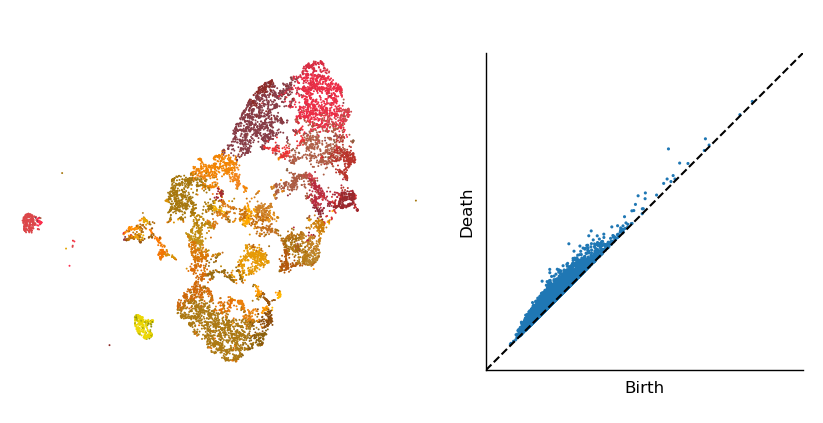

In [542]:
fig, ax = plt.subplots(nrows=1, ncols=n_cols, figsize=(4, 2), constrained_layout=True, width_ratios=width_ratios[::-1])

plot_dgm_loops(res, embd=embd[mask_orange], y=d['clusterColors'][d['clusters']], n_loops=0, ax=ax[::-1], plot_only=[1],
               style=style_file, linewidth=1, plot_loops=plot_loops, s=2)

for s in range(n_cols - 1):
    ax[s].set_xlim(-85, -0)

ax[1].legend().set_visible(False)
ax[1].set_xticks([])
ax[1].set_yticks([])

# fig.savefig(os.path.join(get_path("figures"), f"yao_smart_orange_dgms_eucl_no_loops.png"), dpi=300)

# 7*7 fig

In [642]:
dataset = "yao_smart_orange"
all_res = load_multiple_res(datasets=dataset, n=None, embd_dims=None, sigmas=None, distances=distances, seeds=seeds, root_path=root_path, n_threads=1)

Done with yao_smart_orange None euclidean n_outliers=0, perturbation=None
Done with yao_smart_orange None diffusion_k_15_t_8_kernel_sknn_include_self_False n_outliers=0, perturbation=None
Done with yao_smart_orange None diffusion_k_100_t_8_kernel_sknn_include_self_False n_outliers=0, perturbation=None
Done with yao_smart_orange None diffusion_k_15_t_64_kernel_sknn_include_self_False n_outliers=0, perturbation=None
Done with yao_smart_orange None diffusion_k_100_t_64_kernel_sknn_include_self_False n_outliers=0, perturbation=None
Done with yao_smart_orange None eff_res_corrected_True_weighted_False_k_15_disconnect_True n_outliers=0, perturbation=None
Done with yao_smart_orange None eff_res_corrected_True_weighted_False_k_100_disconnect_True n_outliers=0, perturbation=None


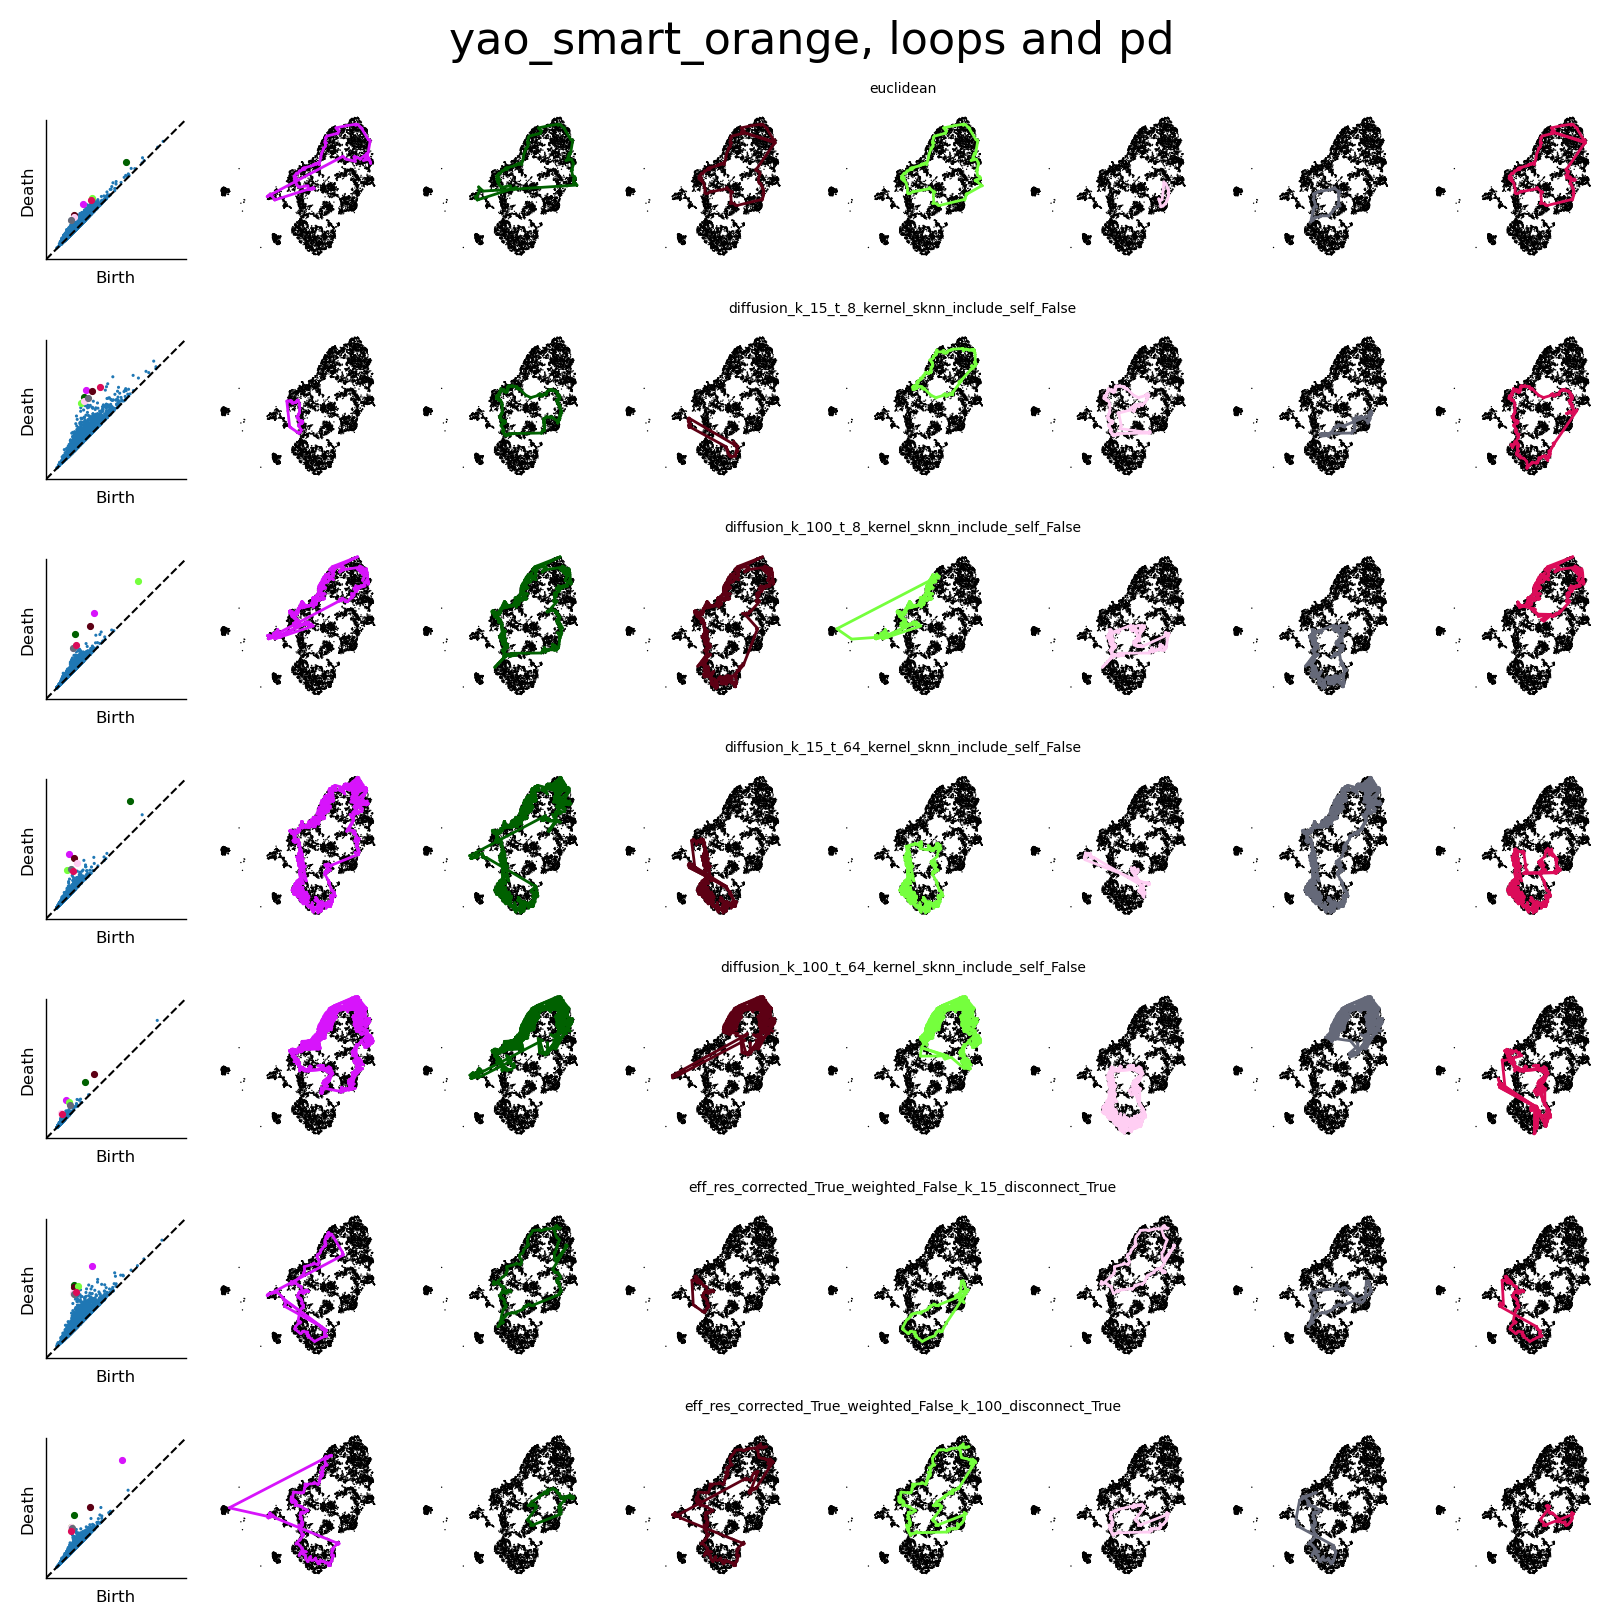

In [ ]:
fig_loops(all_res, embd_n_mask = embd[mask_orange], cell_group_name = "yao_smart_orange", save = False)

# passing cells distribution

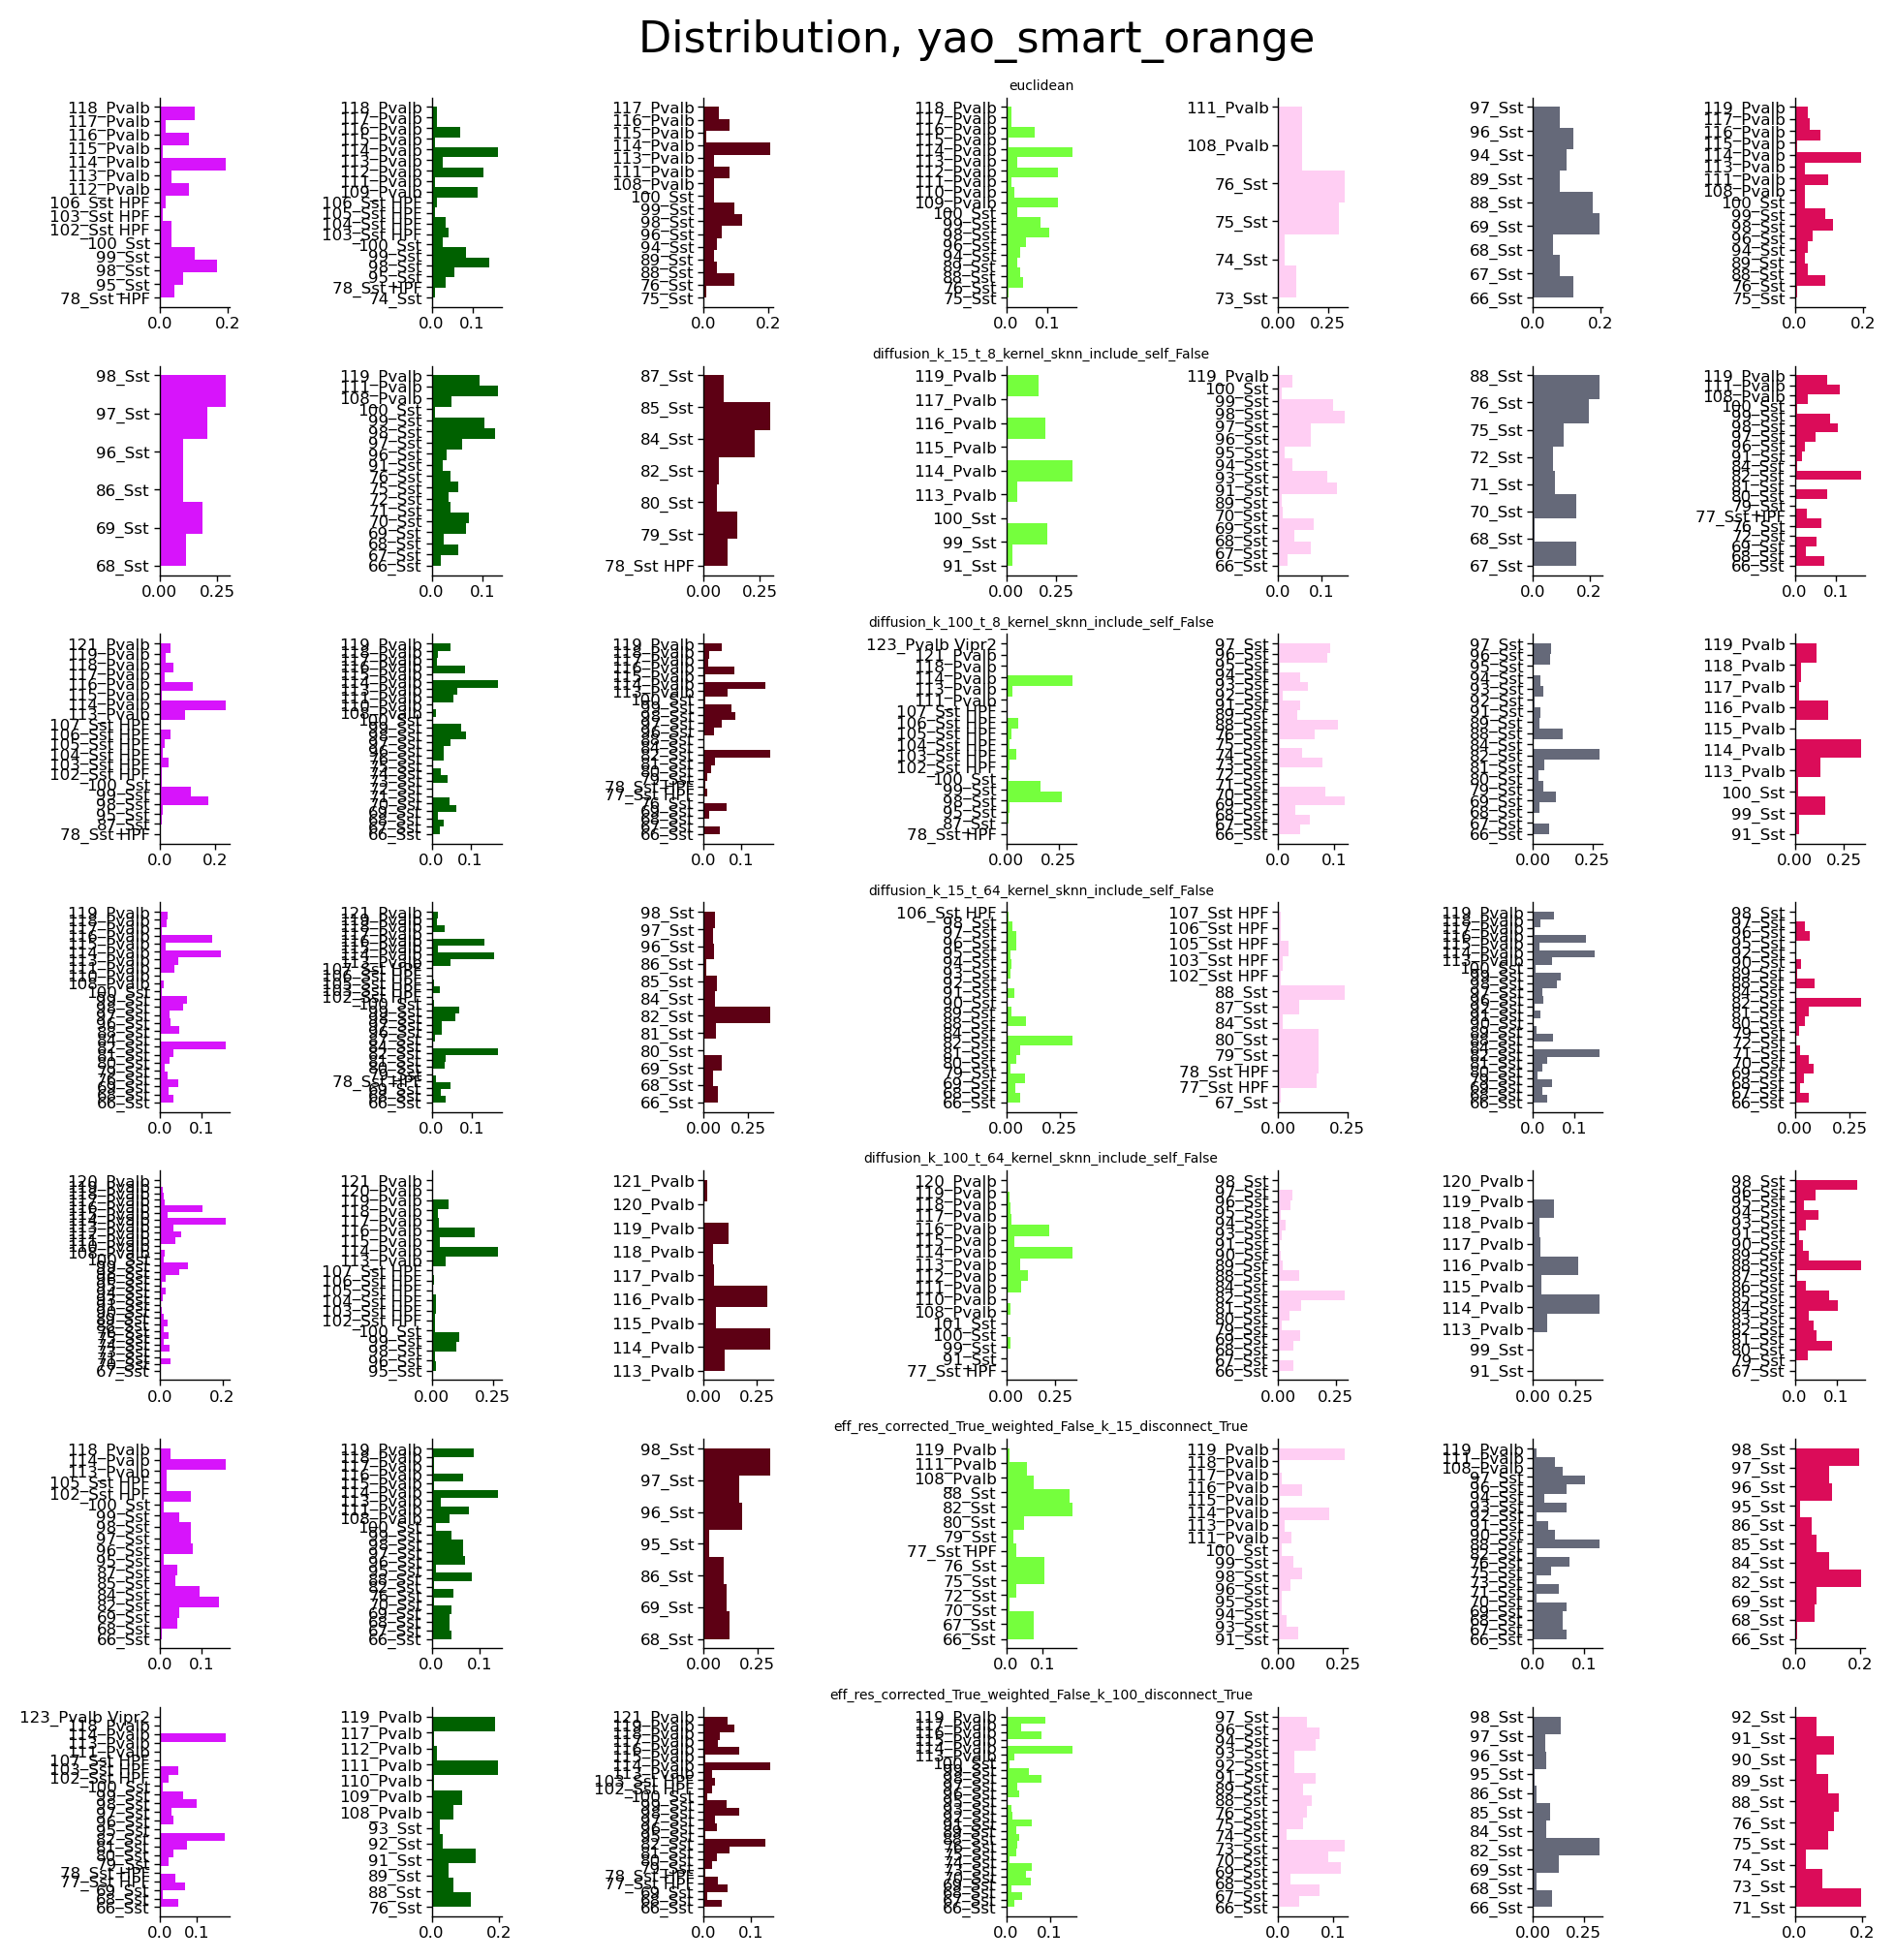

In [ ]:
smart_orange_dict = fig_distribution(all_res, cell_group_name= "yao_smart_orange", clusters = cluster_orange, full_d = full_d, mask = mask_orange, save_fig = False)

In [ ]:
save_dict(smart_orange_dict, os.path.join(get_path("data"), "77test_dist", "dist_smart_orange.pkl"))

# Sorted loop witout smooth

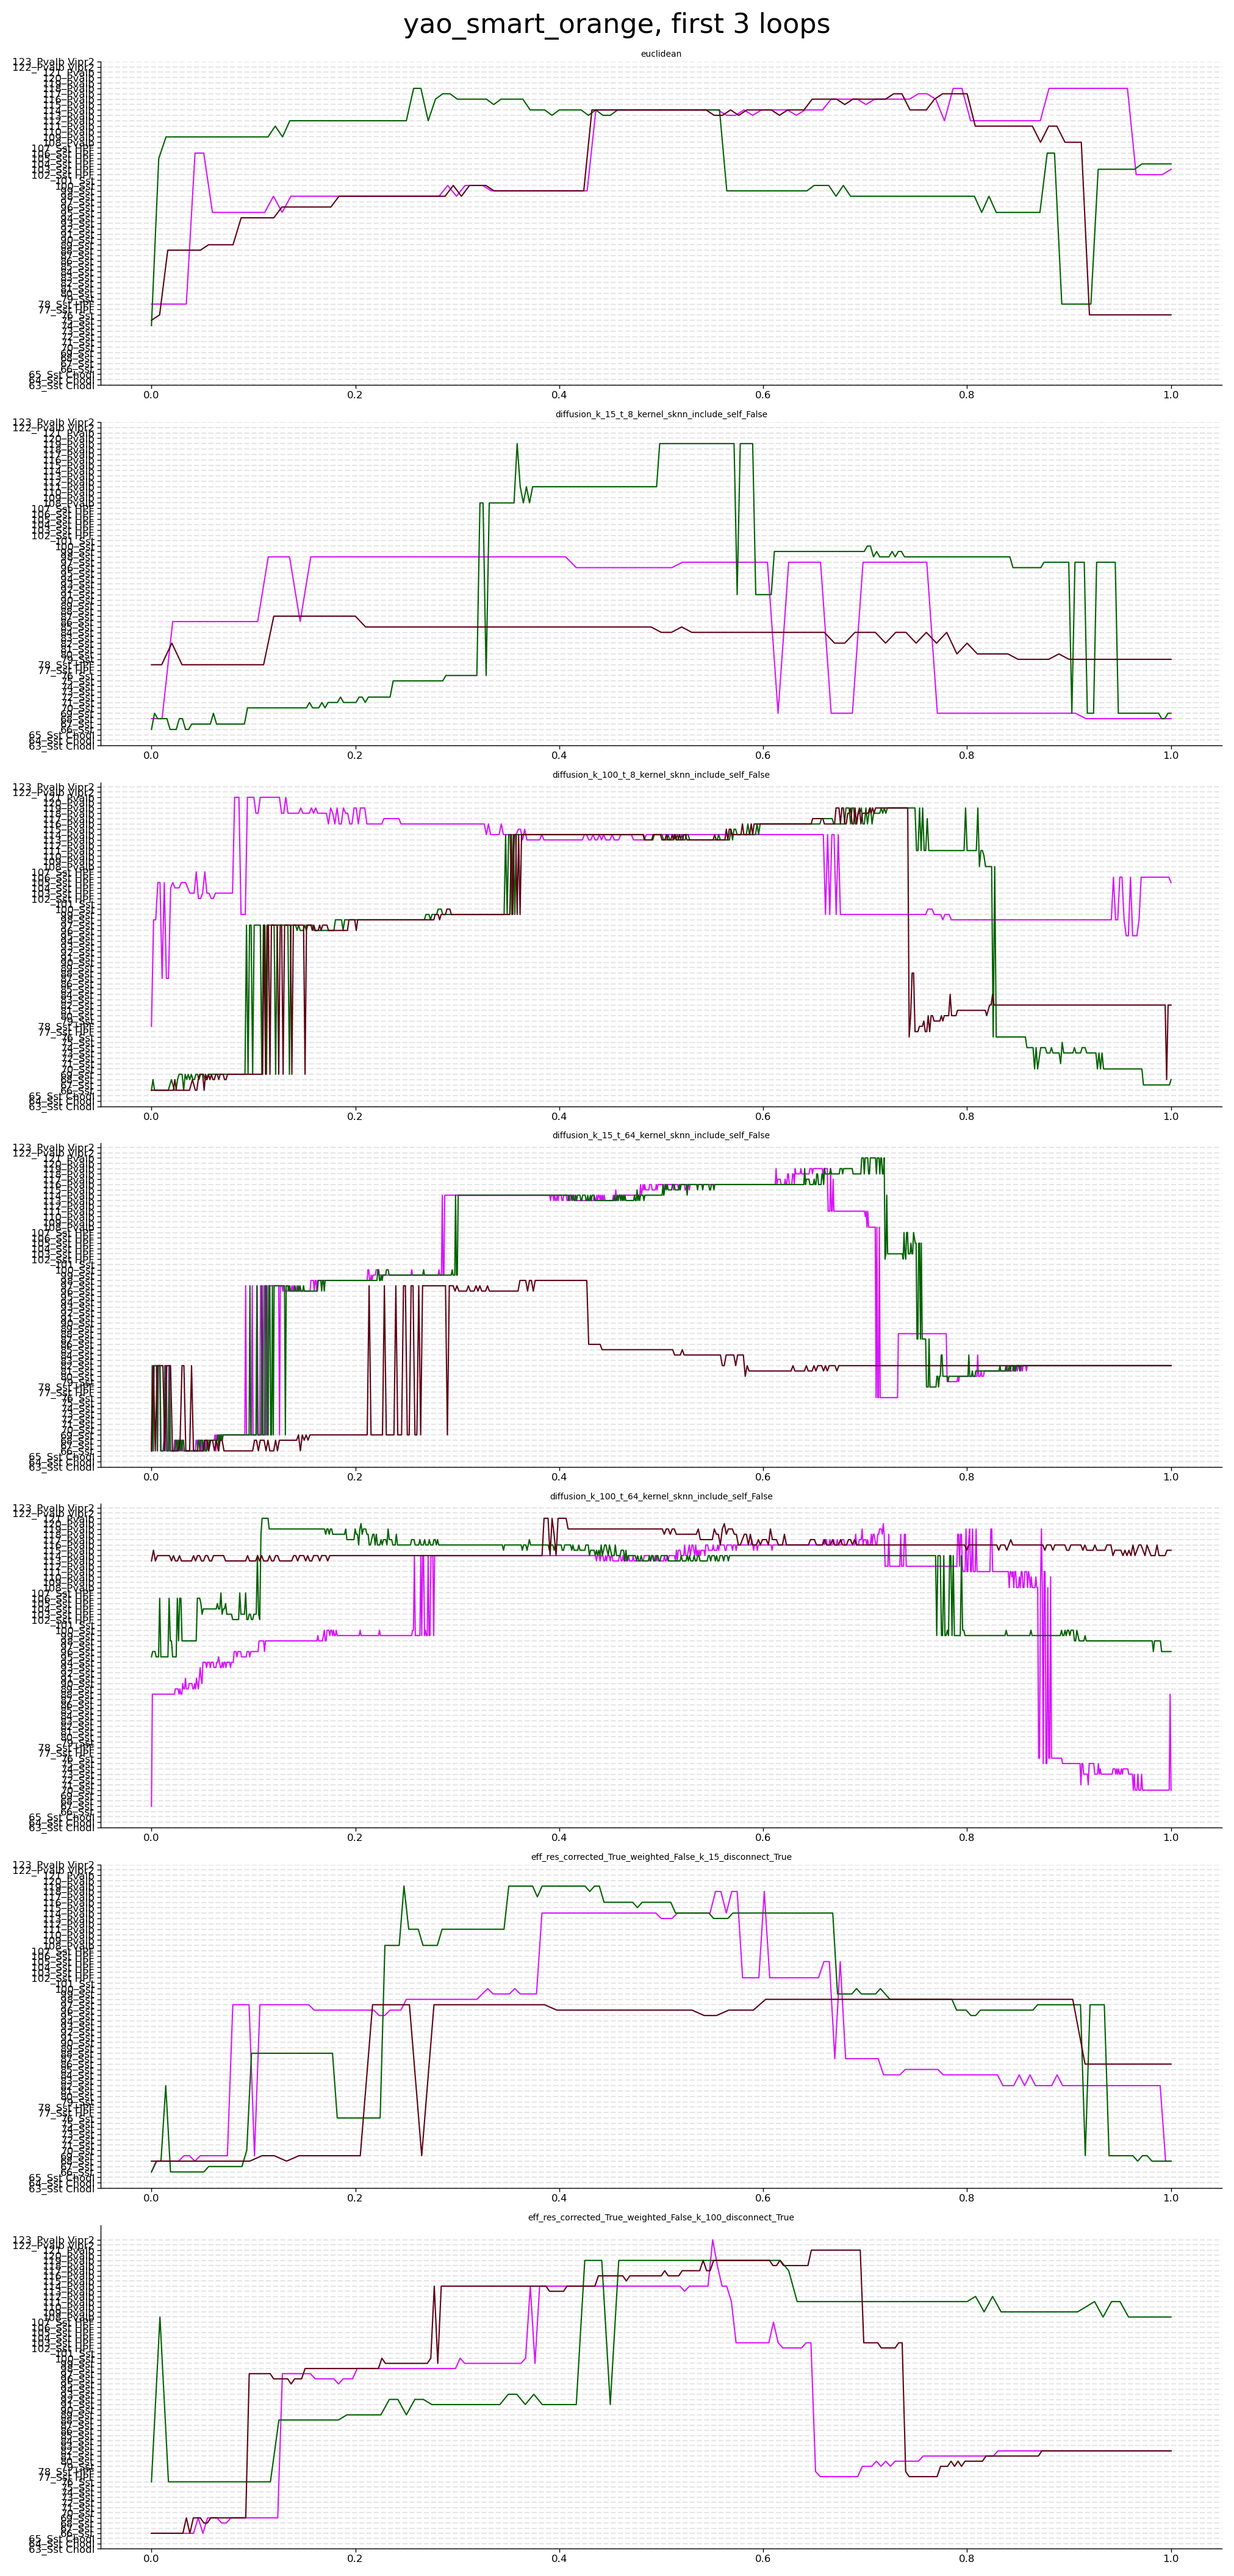

In [ ]:
fig_loops_curve(all_res, n_loops = 3, cell_group_name= "yao_smart_orange", clusters = cluster_orange, full_d = full_d, mask = mask_orange, smooth = False, save_fig = False)

# smooth

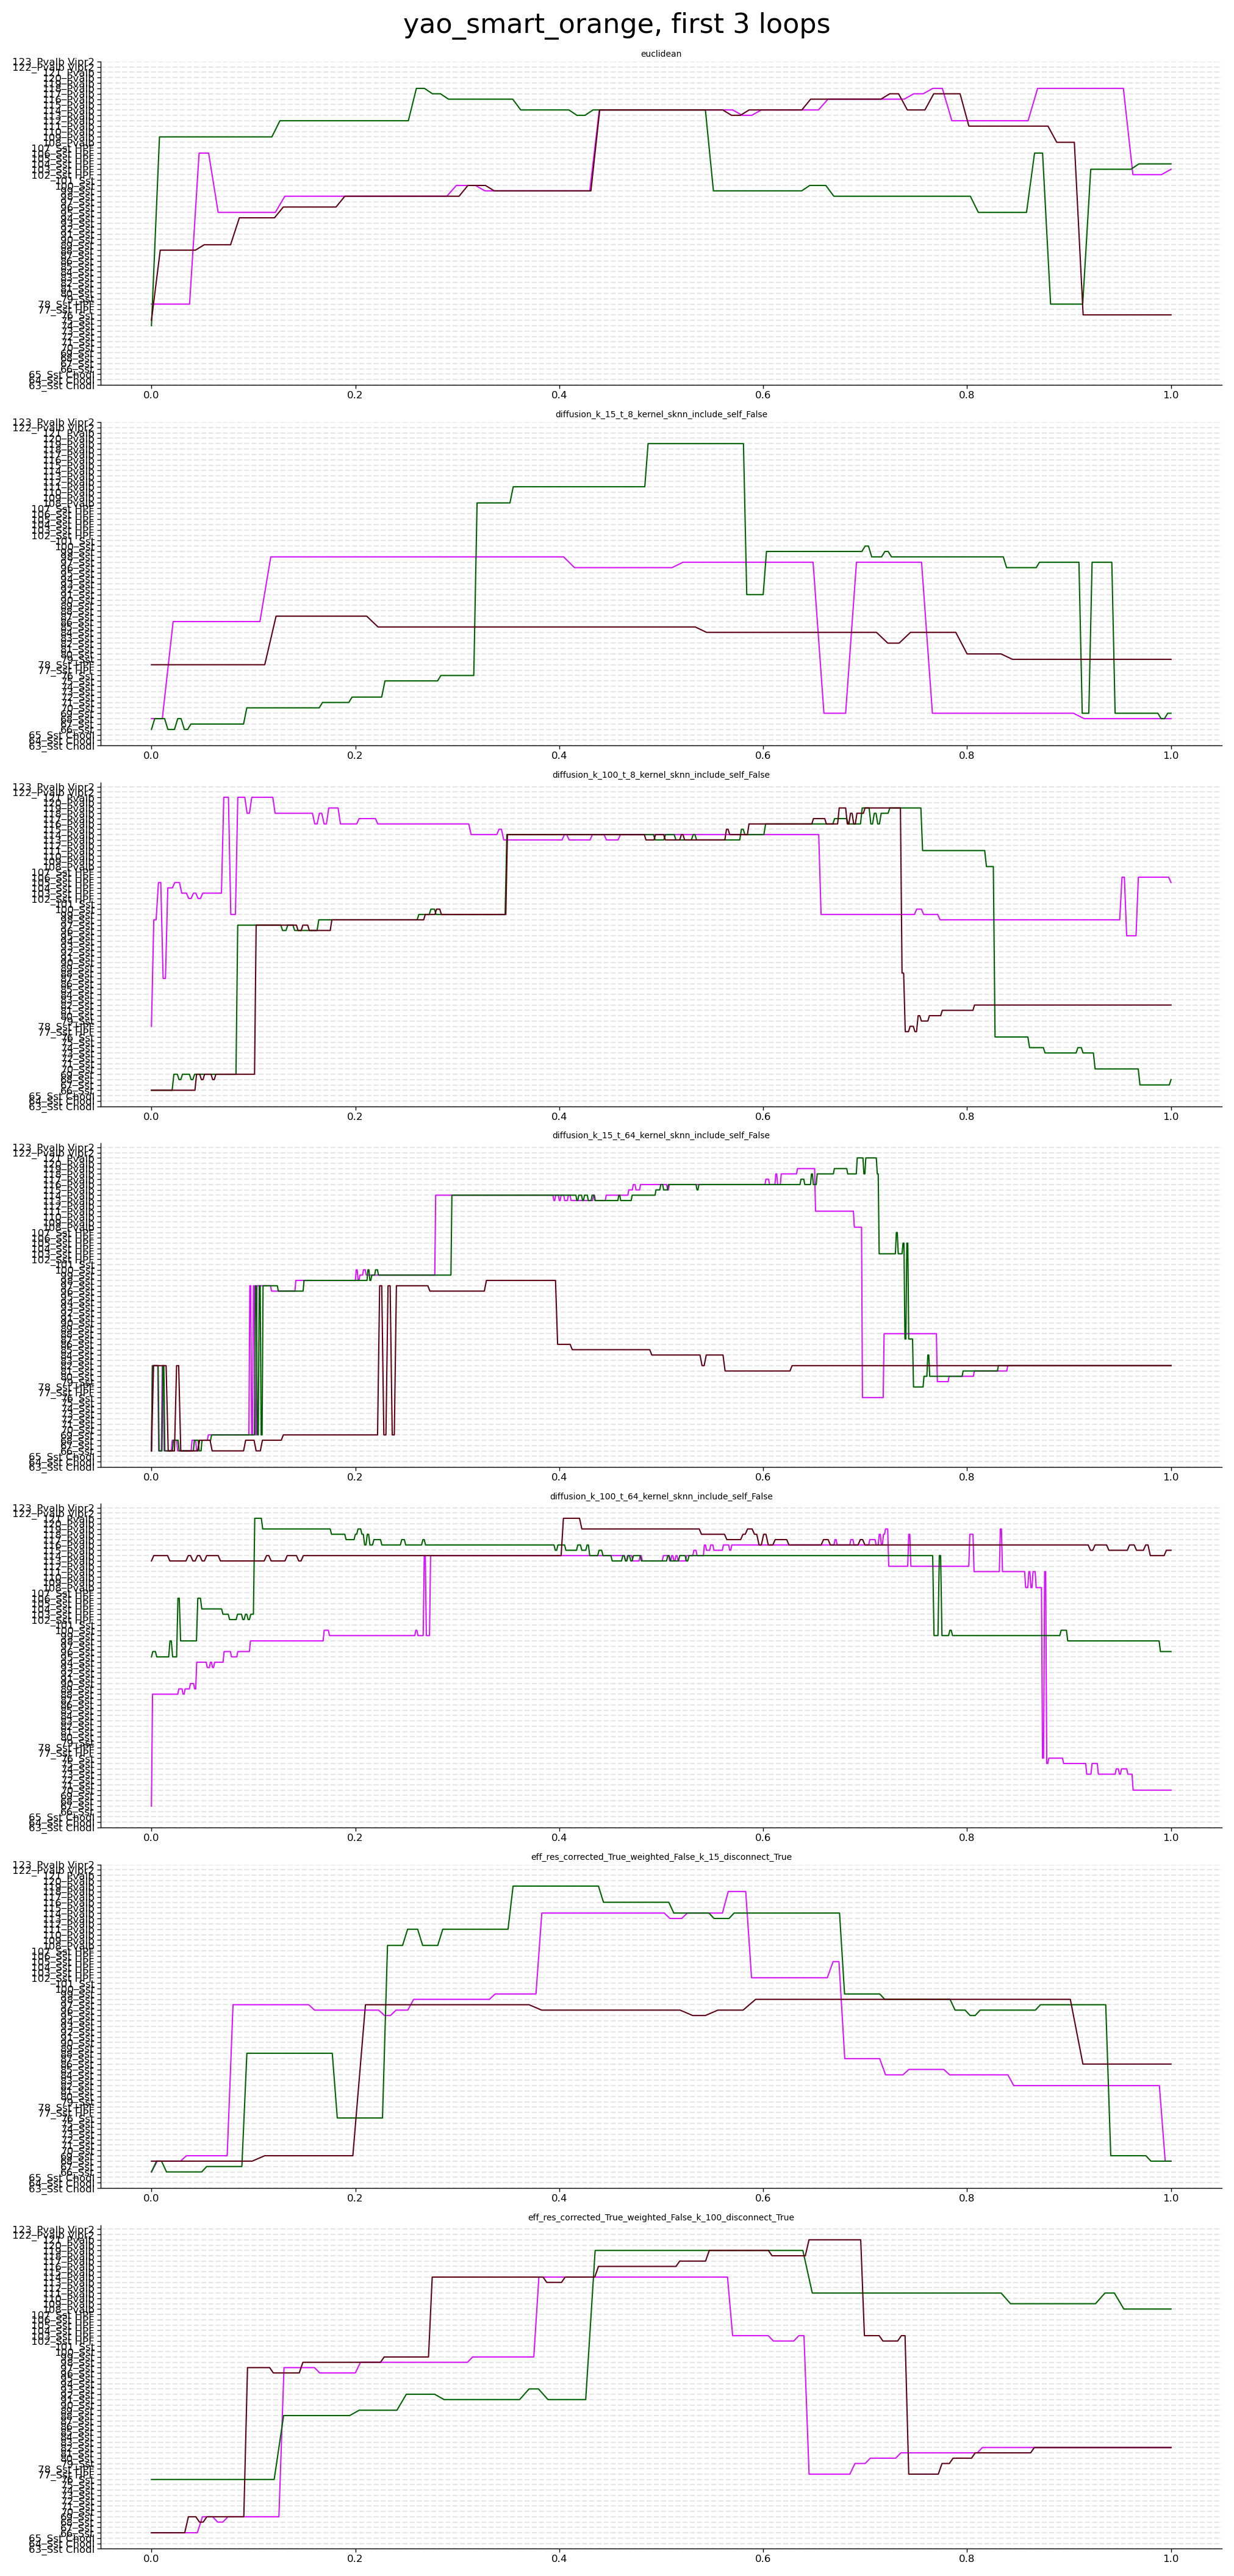

In [ ]:
fig_loops_curve(all_res, n_loops = 3, cell_group_name= "yao_smart_orange", clusters = cluster_orange, full_d = full_d, mask = mask_orange, smooth = True, save_fig = False)